# Understanding swizzling

This notebook is written to play with swizzle parameters using the [swizzle method from cutlass](https://github.com/NVIDIA/cutlass/blob/main/python/pycute/swizzle.py).

## Imports, classes, functions

In [ ]:
from typing import Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [31]:
# The following code taken and modified from https://github.com/NVIDIA/cutlass/blob/main/python/pycute/swizzle.py.

def shiftr(a, s):
  return a >> s if s > 0 else shiftl(a, -s)


def shiftl(a, s):
  return a << s if s > 0 else shiftr(a, -s)


class Swizzle:
    """Performs swizzling operations given the parameters bits_num, base, and shift.

        Given the following operation example:
            i = i ^ ((i & 111000000) >> 3)

        - i indicates the offset or the index to be transformed
        - 111000000 is the yyy_mask
            - the number of zeroes comes from (base + shift) where
                - base indicates the number of least-significant bits to keep constant
                - shift indicates the distance to shift
            - `111` comes from (1 << bits_num) - 1
        - 3 from `>> 3` is the number to shift
    """
    def __init__(self, bits_num, base, shift):
        assert bits_num >= 0
        assert base >= 0
        assert shift >= 0
        assert abs(shift) >= bits_num
        self.bits_num = bits_num
        self.base = base
        self.shift = shift
        bit_mask = (1 << bits_num) - 1
        self.yyy_mask = bit_mask << (base + max(0,shift))

    # operator ()    (transform integer)
    def __call__(self, offset):
        return offset ^ shiftr(offset & self.yyy_mask, self.shift)

In [53]:
def plot_matrix(
    bank_array: np.ndarray,
    annotate_array: np.ndarray,
    num_rows: int,
    num_cols: int,
    title: str = "",
    hline_iter: int = -1,
):
    plt.close()
    
    bank_array     = bank_array.astype(int)
    annotate_array = annotate_array.astype(int)

    _, ax = plt.subplots(figsize=(10, 20))
    ax.imshow(bank_array, cmap="tab20")
    ax.set_xticks(np.arange(num_cols)-0.5, minor=True)
    ax.set_yticks(np.arange(num_rows)-0.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=1.5)

    # Add bank annotations.
    for i in range(bank_array.shape[0]):
        for j in range(bank_array.shape[1]):
            ax.text(j, i, annotate_array[i, j], ha="center", va="center", color="w", size="small")

    if hline_iter > 0:
        for row_idx in range(1, num_rows // hline_iter):
            ax.axhline(y=(row_idx * hline_iter) - 0.5, color="black", linestyle='--', linewidth=2)

    plt.title(title) 
    plt.tight_layout()
    plt.show()

## Parameters

The parameters are as follows.

| name | description |
| -- | -- |
| M | The number of rows in the matrix |
| N | The number of columns in the matrix |
| element_size | The size of elements in bytes, which determines how many elements assigned consecutively in each bank |
| swizzle_num_mask_bits | The number of swizzle mask bits |
| swizzle_num_base | The number of swizzle base bits |
| swizzle_num_shift | The number of swizzle shift bits |

In [4]:
# Initialize parameters.
M = 64
N = 16
element_size = 2

In [5]:
# Initialize the matrix with offsets as its values.
matrix = np.arange(M * N).reshape((M, N))
matrix

array([[   0,    1,    2, ...,   13,   14,   15],
       [  16,   17,   18, ...,   29,   30,   31],
       [  32,   33,   34, ...,   45,   46,   47],
       ...,
       [ 976,  977,  978, ...,  989,  990,  991],
       [ 992,  993,  994, ..., 1005, 1006, 1007],
       [1008, 1009, 1010, ..., 1021, 1022, 1023]], shape=(64, 16))

In [7]:
# Divide the matrix into banks.
matrix_by_bank = ((matrix % (32 * 4 / element_size)) // (4 / element_size)).astype(int)
matrix_by_bank

array([[ 0,  0,  1, ...,  6,  7,  7],
       [ 8,  8,  9, ..., 14, 15, 15],
       [16, 16, 17, ..., 22, 23, 23],
       ...,
       [ 8,  8,  9, ..., 14, 15, 15],
       [16, 16, 17, ..., 22, 23, 23],
       [24, 24, 25, ..., 30, 31, 31]], shape=(64, 16))

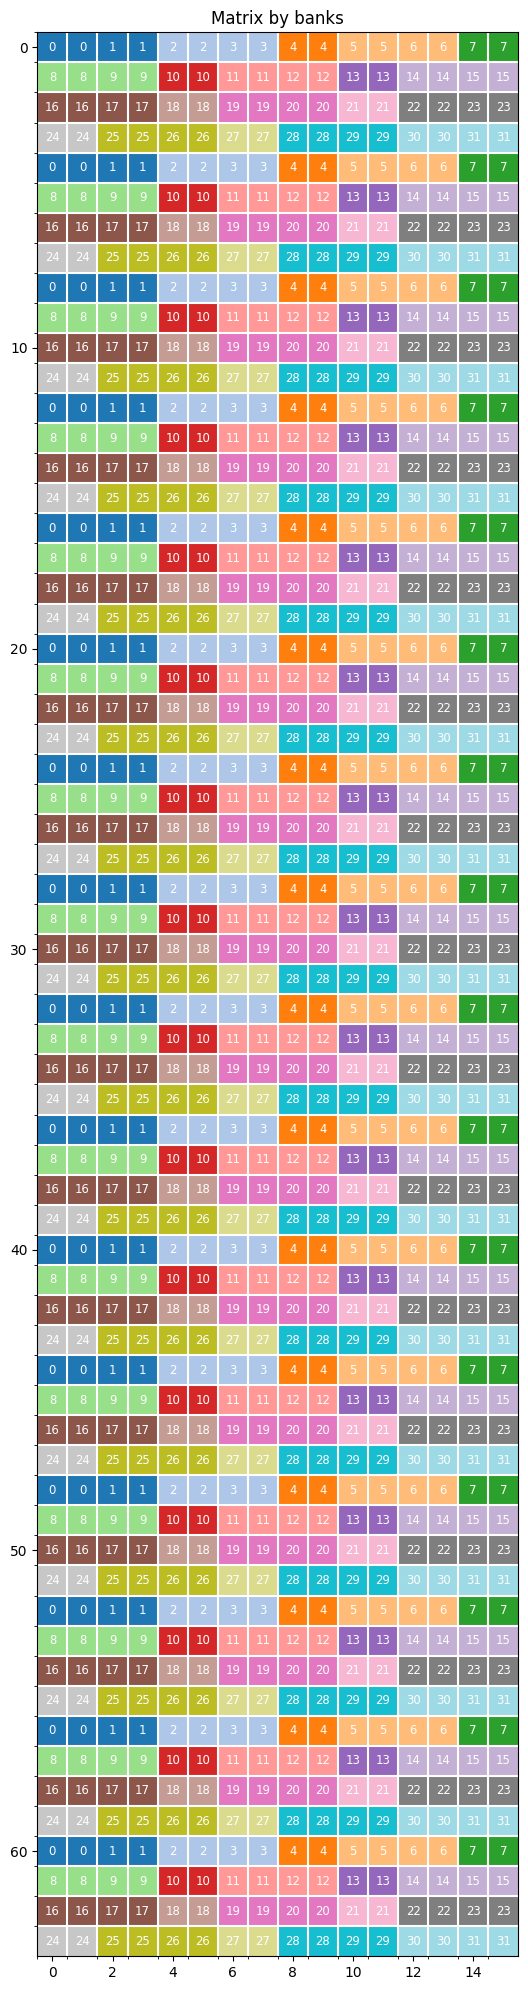

In [10]:
# Visualize the elements in As colored by banks.
plot_matrix(
    matrix_by_bank, matrix_by_bank, M, N, "Matrix by banks")

## Performing swizzling

In [48]:
def perform_swizzle(swizzle_op: Swizzle, matrix: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Performs swizzle on matrix and returns the updated banks."""
    updated_banks = np.zeros(matrix.shape).astype(int)
    swizzled_matrix          = np.zeros(matrix.shape).astype(int)

    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            offset         = matrix[row_idx, col_idx]
            updated_offset = swizzle_op(offset)
            new_row_idx    = updated_offset // matrix.shape[1]
            new_col_idx    = updated_offset % matrix.shape[1]
            swizzled_matrix[new_row_idx, new_col_idx] = matrix[row_idx, col_idx]
            updated_banks[row_idx, col_idx] = int((updated_offset % (32 * 4 / element_size)) // (4 / element_size))
            if offset == 64:
                print(updated_offset)

    return updated_banks, swizzled_matrix

In [49]:
# Feel free to play around with the values below.
base     = 3 # 8 elements should always be packed together.
bits_num = 3 # 8 groups (64 / 8) to permute.
# abs(shift) >= bits_num
shift    = 3 # each full-bank "row" contains 64 elements; log2(64) - base

# Create the swizzle_op object.
swizzle_op = Swizzle(bits_num, base, shift)
swizzled_matrix_by_banks, swizzled_matrix = perform_swizzle(swizzle_op, matrix)

72


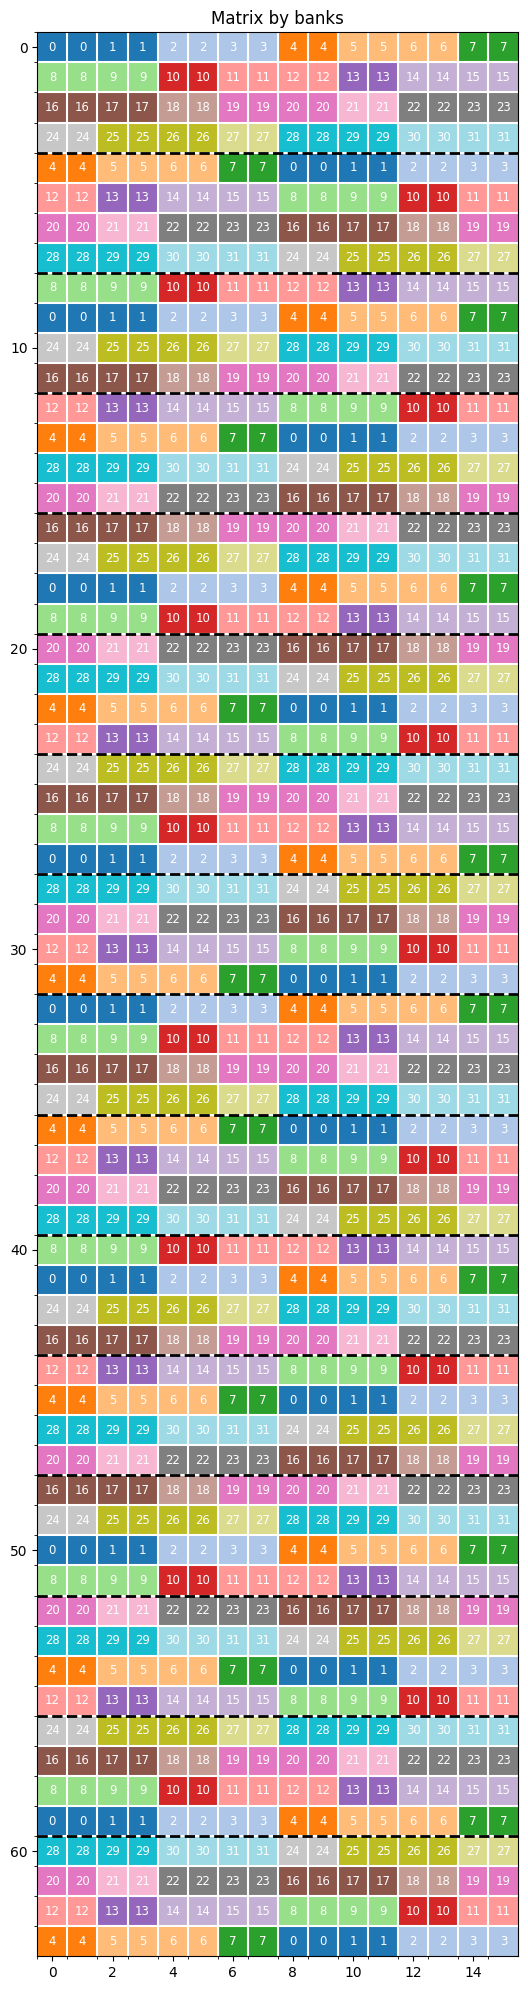

In [54]:
plot_matrix(
    swizzled_matrix_by_banks, swizzled_matrix_by_banks, M, N, "Matrix by banks", 4)

In [55]:
swizzled_matrix

array([[   0,    1,    2, ...,   13,   14,   15],
       [  16,   17,   18, ...,   29,   30,   31],
       [  32,   33,   34, ...,   45,   46,   47],
       ...,
       [1000, 1001, 1002, ...,  997,  998,  999],
       [ 984,  985,  986, ...,  981,  982,  983],
       [ 968,  969,  970, ...,  965,  966,  967]], shape=(64, 16))